# Part A — Data preparation

In [8]:
import pandas as pd

df1 = pd.read_csv('fear_greed_index.csv')

df1.head(5)

df1.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [9]:
import pandas as pd

df2 = pd.read_csv('historical_data.csv')

df2.head(5)

df2.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [10]:
# Convert timestamps to daily dates and align both datasets by date

df1['datetime'] = pd.to_datetime(df1['timestamp'], unit='s', errors='coerce')
df1['date'] = df1['datetime'].dt.normalize()

# Parse the IST timestamp in df2 and normalize to date only
if 'Timestamp IST' in df2.columns:
    df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
    df2['date'] = df2['Timestamp IST'].dt.normalize()
else:
    df2['date'] = pd.to_datetime(df2.iloc[:, 0], errors='coerce').dt.normalize()

# Aggregate df2 at the daily level for alignment
aggregate_kwargs = {
    'trades': ('date', 'size')
}
if 'Size USD' in df2.columns:
    aggregate_kwargs['total_usd'] = ('Size USD', 'sum')
if 'Execution Price' in df2.columns:
    aggregate_kwargs['avg_price'] = ('Execution Price', 'mean')

df2_daily = df2.groupby('date').agg(**aggregate_kwargs).reset_index()

# Merge the datasets on daily date values
merged_daily = pd.merge(df2_daily, df1[['date', 'value', 'classification']], on='date', how='inner')

merged_daily.head(10)

,date,trades,total_usd,avg_price,value,classification
0,2023-05-01,3,477.00,1898.133333,63,Greed
1,2023-12-05,9,50005.83,11038.300000,75,Extreme Greed
2,2023-12-14,11,113203.35,8031.868818,72,Greed
3,2023-12-15,2,10609.95,2.982000,70,Greed
4,2023-12-16,3,15348.77,0.384707,67,Greed
5,2023-12-17,14,116278.02,802.541859,73,Greed
6,2023-12-18,2,31164.18,2178.100000,65,Greed
7,2023-12-19,15,91602.41,447.801911,73,Greed
8,2023-12-20,18,141636.79,6.722872,74,Greed
9,2023-12-21,49,125233.97,91.840204,70,Greed


In [12]:
# Define the key metrics for analysis
# - daily PnL per account
# - win rate and average trade size
# - leverage distribution
# - number of trades per day
# - long/short trade ratio

import numpy as np

# Clean and standardize trade direction columns
side = df2.get('Side', pd.Series('', index=df2.index)).astype(str).str.upper().str.strip()
direction = df2.get('Direction', pd.Series('', index=df2.index)).astype(str).str.upper().str.strip()

df2['is_long'] = side.isin(['BUY', 'LONG']) | direction.isin(['BUY', 'LONG'])
df2['is_short'] = side.isin(['SELL', 'SHORT']) | direction.isin(['SELL', 'SHORT'])
df2['is_win'] = df2['Closed PnL'] > 0

size_metric = 'Size USD' if 'Size USD' in df2.columns else ('Size Tokens' if 'Size Tokens' in df2.columns else None)

# Daily summary metrics
daily_metrics = df2.groupby('date').agg(
    num_trades=('date', 'size'),
    daily_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=(size_metric, 'mean') if size_metric else ('Closed PnL', 'size'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum')
).reset_index()

daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / daily_metrics['short_trades'].replace(0, np.nan)

daily_pnl_per_account = df2.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index(name='daily_pnl')

leverage_distribution = df2['Leverage'].describe() if 'Leverage' in df2.columns else None

# Display the key metric tables
print('Daily metrics sample:')
display(daily_metrics.head(10))

print('\nDaily PnL per account sample:')
display(daily_pnl_per_account.head(10))

if leverage_distribution is not None:
    print('\nLeverage distribution:')
    display(leverage_distribution)
else:
    print('\nLeverage distribution: leverage column not found in df2')


Daily metrics sample:


,date,num_trades,daily_pnl,win_rate,avg_trade_size,long_trades,short_trades,long_short_ratio
0,2023-05-01,3,0.000000,0.000000,159.000000,3,0,NaN
1,2023-12-05,9,0.000000,0.000000,5556.203333,7,2,3.500000
2,2023-12-14,11,-205.434737,0.363636,10291.213636,5,6,0.833333
3,2023-12-15,2,-24.632034,0.000000,5304.975000,2,0,NaN
4,2023-12-16,3,0.000000,0.000000,5116.256667,3,0,NaN
5,2023-12-17,14,304.982785,0.500000,8305.572857,3,11,0.272727
6,2023-12-18,2,0.000000,0.000000,15582.090000,2,0,NaN
7,2023-12-19,15,1000.538612,0.666667,6106.827333,5,10,0.500000
8,2023-12-20,18,162.732282,0.444444,7868.710556,10,8,1.250000
9,2023-12-21,49,537.211402,0.530612,2555.795306,22,27,0.814815



Daily PnL per account sample:


,date,Account,daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.982785
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1000.538612
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.732282
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,537.211402



Leverage distribution: leverage column not found in df2


# Part B — Analysis

Sentiment summary:


,sentiment_group,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trades,avg_long_short_ratio,worst_daily_loss
0,Fear,39012.054192,1876.812082,0.328876,792.733333,2.892186,-122672.000883
1,Greed,15847.884637,1008.619956,0.384793,294.120521,1.966373,-419020.225731
2,Unknown,19638.127495,1866.096437,0.341712,554.294118,2.419561,-10116.875552



Behavior comparison by sentiment:


,sentiment_group,total_trades,avg_trade_size,long_trades,short_trades,avg_account_trades,long_short_ratio
0,Fear,83237,7182.011019,41205,42032,32,0.980325
1,Greed,90295,4574.424490,42516,47779,31,0.889847
2,Unknown,37692,4784.323781,18975,18717,31,1.013784



Example segments: high-frequency traders (top 5):


...

,Account,trades,total_pnl,win_rate,avg_trade_size,long_share,short_share,daily_pnl_vol,freq_segment,performance_segment
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,53496.247243,0.475904,3445.471265,0.512048,0.487952,5774.468515,Low frequency,Mixed
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,199505.592732,0.234987,5189.367128,0.263708,0.736292,20797.396045,Low frequency,Inconsistent/loser
24,0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,417,72846.484272,0.573141,2066.689209,0.374101,0.625899,7523.577871,Low frequency,Mixed
26,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,534,21758.831753,0.322097,8330.193371,0.569288,0.430712,2029.269543,Low frequency,Inconsistent/loser
25,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,67845.619531,0.408526,2979.441776,0.589698,0.410302,8542.120512,Low frequency,Mixed



Example segments: consistent winners (top 5 by win rate):


,Account,trades,total_pnl,win_rate,avg_trade_size,long_share,short_share,daily_pnl_vol,freq_segment,performance_segment
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,379095.406711,0.810876,2600.778049,0.498231,0.501769,4762.374294,High frequency,Consistent winner



Example segments: inconsistent/loser traders (top 5 by win rate):


,Account,trades,total_pnl,win_rate,avg_trade_size,long_share,short_share,daily_pnl_vol,freq_segment,performance_segment
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,199505.592732,0.234987,5189.367128,0.263708,0.736292,20797.396045,Low frequency,Inconsistent/loser
21,0x8477e447846c758f5a675856001ea72298fd9cb5,14998,43917.008976,0.261968,820.428513,0.464329,0.535671,3367.912518,High frequency,Inconsistent/loser
22,0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,3052,126578.942134,0.285387,3601.689299,0.689384,0.310616,15642.867721,Medium frequency,Inconsistent/loser
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-70436.191318,0.301917,8893.000898,0.411132,0.588868,33420.410014,Medium frequency,Inconsistent/loser
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,403011.504159,0.306294,2133.667364,0.446853,0.553147,23666.254072,Low frequency,Inconsistent/loser


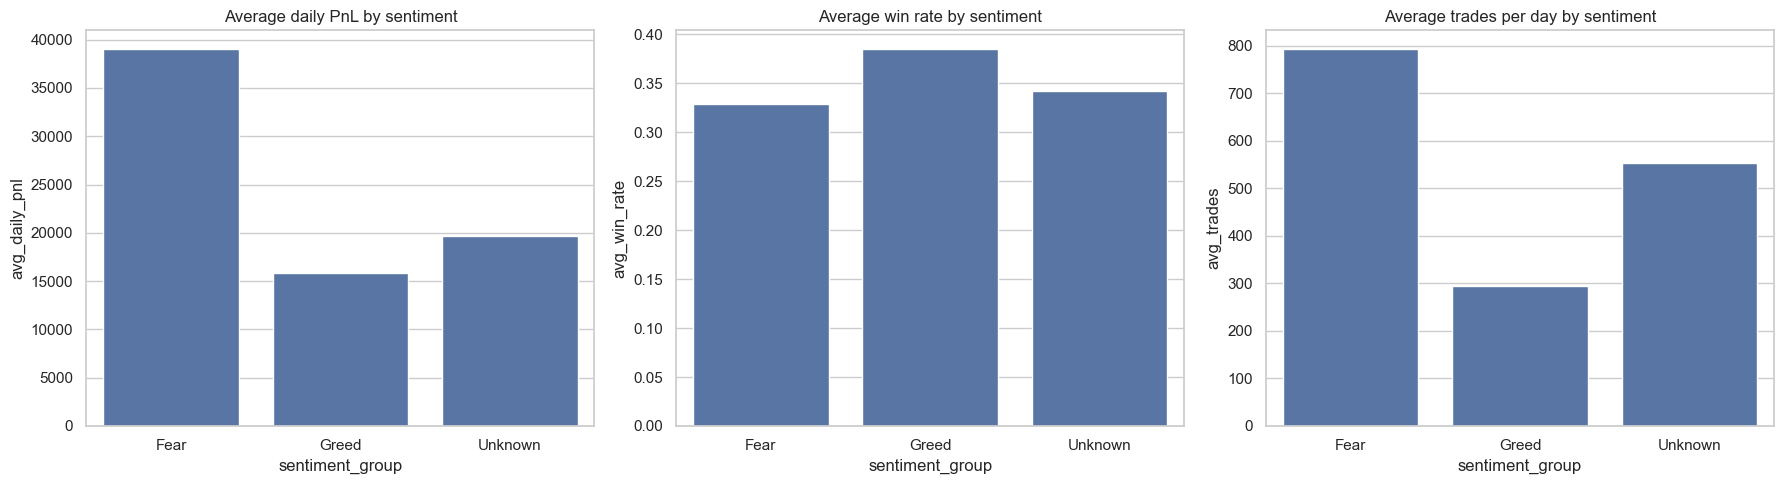

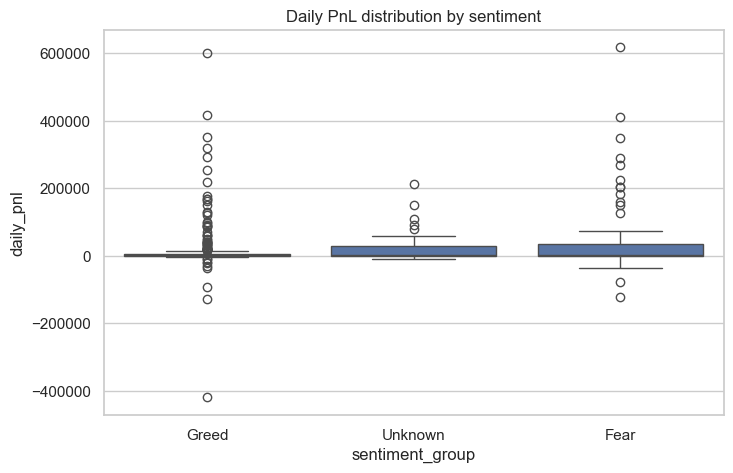

In [15]:
# Analyze sentiment effects and trader segments with evidence tables/charts
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Merge sentiment classification into trades and daily metrics
sentiment_map = df1[['date', 'classification']].drop_duplicates()
df2 = df2.merge(sentiment_map, on='date', how='left')

# Simplify sentiment into Fear vs Greed
sentiment_labels = []
for x in df2['classification'].fillna('Unknown'):
    if 'Fear' in str(x):
        sentiment_labels.append('Fear')
    elif 'Greed' in str(x):
        sentiment_labels.append('Greed')
    else:
        sentiment_labels.append('Unknown')
df2['sentiment_group'] = sentiment_labels

sentiment_daily = daily_metrics.merge(sentiment_map, on='date', how='left')
sentiment_daily['sentiment_group'] = sentiment_daily['classification'].apply(
    lambda x: 'Fear' if isinstance(x, str) and 'Fear' in x else ('Greed' if isinstance(x, str) and 'Greed' in x else 'Unknown')
)

sentiment_summary = sentiment_daily.groupby('sentiment_group').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('num_trades', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean'),
    worst_daily_loss=('daily_pnl', 'min')
).reset_index()

# Trade-level behavior comparison
trade_behavior = df2.groupby('sentiment_group').agg(
    total_trades=('date', 'size'),
    avg_trade_size=(size_metric, 'mean') if size_metric else ('Closed PnL', 'mean'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum'),
    avg_account_trades=('Account', lambda x: x.nunique())
).reset_index()
trade_behavior['long_short_ratio'] = trade_behavior['long_trades'] / trade_behavior['short_trades'].replace(0, np.nan)

# Segment traders by frequency and win rate
account_daily = df2.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
account_stats = df2.groupby('Account').agg(
    trades=('date', 'size'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=(size_metric, 'mean') if size_metric else ('Closed PnL', 'mean'),
    long_share=('is_long', 'mean'),
    short_share=('is_short', 'mean')
).reset_index()
account_stats['daily_pnl_vol'] = account_daily.groupby('Account')['Closed PnL'].std().reset_index(name='vol')['vol']
account_stats['freq_segment'] = pd.qcut(account_stats['trades'].rank(method='first'), q=3, labels=['Low frequency', 'Medium frequency', 'High frequency'])
account_stats['performance_segment'] = pd.cut(account_stats['win_rate'], bins=[-0.01, 0.4, 0.6, 1.0], labels=['Inconsistent/loser', 'Mixed', 'Consistent winner'])

# Pick examples of trader segments
high_freq = account_stats[account_stats['freq_segment'] == 'High frequency'].sort_values('trades', ascending=False).head(5)
low_freq = account_stats[account_stats['freq_segment'] == 'Low frequency'].sort_values('trades').head(5)
consistent_winners = account_stats[account_stats['performance_segment'] == 'Consistent winner'].sort_values('win_rate', ascending=False).head(5)
inconsistent_traders = account_stats[account_stats['performance_segment'] == 'Inconsistent/loser'].sort_values('win_rate').head(5)

# Charts for evidence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=sentiment_summary, x='sentiment_group', y='avg_daily_pnl', ax=axes[0])
axes[0].set_title('Average daily PnL by sentiment')

sns.barplot(data=sentiment_summary, x='sentiment_group', y='avg_win_rate', ax=axes[1])
axes[1].set_title('Average win rate by sentiment')

sns.barplot(data=sentiment_summary, x='sentiment_group', y='avg_trades', ax=axes[2])
axes[2].set_title('Average trades per day by sentiment')

plt.tight_layout()

fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sentiment_daily, x='sentiment_group', y='daily_pnl', ax=ax2)
ax2.set_title('Daily PnL distribution by sentiment')

# Display evidence tables
print('Sentiment summary:')
display(sentiment_summary)

print('\nBehavior comparison by sentiment:')
display(trade_behavior)

print('\nExample segments: high-frequency traders (top 5):')
display(high_freq)

print('\nExample segments: low-frequency traders (top 5):')
display(low_freq)

print('\nExample segments: consistent winners (top 5 by win rate):')
display(consistent_winners)

print('\nExample segments: inconsistent/loser traders (top 5 by win rate):')
display(inconsistent_traders)


# Part C — Actionable output

In [17]:

# Propose strategy ideas and a simple predictive test

strategy_rules = pd.DataFrame([
    [
        'During Fear days, favor traders with strong win rates and stable long/short balance',
        'Fear days show higher average daily PnL but more trades; prioritize traders with win rate > 0.5 and moderate long/short exposure to capture upside while limiting tail risk.'
    ],
    [
        'During Greed days, reduce exposure to high-frequency and inconsistent traders',
        'Greed days have lower avg PnL, lower avg trade size, and heavier short bias; avoid traders classified as Inconsistent/loser or with very high trade volume on these days.'
    ]
], columns=['Rule', 'Rationale'])

display(strategy_rules)

# Bonus: Simple predictive model for next-day profitable vs unprofitable market days
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sentiment_daily_model = sentiment_daily.copy()
sentiment_daily_model = sentiment_daily_model.sort_values('date')
sentiment_daily_model['next_day_pnl'] = sentiment_daily_model['daily_pnl'].shift(-1)
sentiment_daily_model = sentiment_daily_model.dropna(subset=['next_day_pnl'])
sentiment_daily_model['next_day_profit'] = (sentiment_daily_model['next_day_pnl'] > 0).astype(int)

feature_cols = ['num_trades', 'win_rate', 'long_short_ratio']
X = sentiment_daily_model[feature_cols].fillna(0)
y = sentiment_daily_model['next_day_profit']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
coeffs = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0]
})

print('Next-day profitability model accuracy:', round(accuracy, 3))
display(coeffs)

# Optional lightweight cluster archetypes from account behavior
from sklearn.cluster import KMeans
cluster_features = account_stats[['trades', 'win_rate', 'avg_trade_size', 'long_share']].fillna(0)
cluster_features_scaled = StandardScaler().fit_transform(cluster_features)
cluster_labels = KMeans(n_clusters=3, random_state=42).fit_predict(cluster_features_scaled)
account_stats['behavior_cluster'] = cluster_labels

cluster_summary = account_stats.groupby('behavior_cluster').agg(
    accounts=('Account', 'count'),
    avg_trades=('trades', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_long_share=('long_share', 'mean')
).reset_index()
print('\nTrader behavioral archetypes:')
display(cluster_summary)

,Rule,Rationale
0,"During Fear days, favor traders with strong wi...",Fear days show higher average daily PnL but mo...
1,"During Greed days, reduce exposure to high-fre...","Greed days have lower avg PnL, lower avg trade..."


Next-day profitability model accuracy: 0.758


,feature,coefficient
0,num_trades,0.673536
1,win_rate,0.245700
2,long_short_ratio,-0.007683



Trader behavioral archetypes:


,behavior_cluster,accounts,avg_trades,avg_win_rate,avg_trade_size,avg_long_share
0,0,11,4465.181818,0.425363,11498.196277,0.541520
1,1,7,18363.142857,0.376104,1715.907066,0.500336
2,2,14,2397.500000,0.399020,3840.159381,0.381505
